<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Procesos-estocasticos/blob/main/descomposicion_canonica_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DESCOMPOSICIÓN CANÓNICA

En una Notebook de Jupyter se pide:

1. Escribir la matriz de transición $P$ y dibujar su diagrama de transiciones.  
2. Determinar si la matriz tiene distribución límite.  
3. Escribir la descomposición canónica de la matriz, determinar el límite de $P^n$ y comparar contra las distribuciones límite de las submatrices.  
4. Escribir un programa que encuentre la descomposición canónica de una matriz dada.


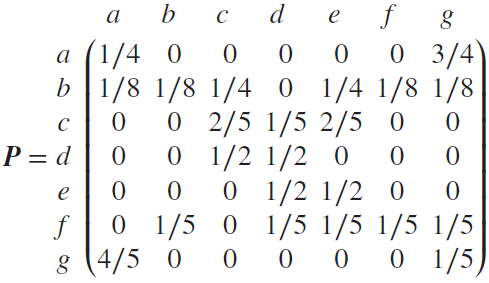

#SOLUCIÓN

# 1. Matriz P y diagrama de transición

### Definiciones

Una cadena de Markov es un proceso $\{X_n\}$ que cumple:

$$
P(X_{n+1}=j \mid X_n=i) = p_{ij}
$$

La matriz de transición $P = (p_{ij})$ cumple:

- $p_{ij} \geq 0$
- $\sum_j p_{ij} = 1$



###  Clasificación de estados

- Estados comunicantes: s conjuntos de estados que se alcanzan mutuamente.
- Clase cerrada: no se puede salir de ella, es decir pertenecen a clases cerradas.
- Estado recurrente: se regresa con probabilidad 1
- Estado transitorio: puede abandonarse definitivamente

In [96]:
# importamos las librerias necesarias

import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Matriz de transición

Sea $E = \{a,b,c,d,e,f,g\}$ el espacio de estados de la cadena de Markov.

Una matriz de transición $P = (p_{ij})$ está definida por:

$$
p_{ij} = P(X_{n+1} = j \mid X_n = i)
$$

donde cada entrada representa la probabilidad de pasar del estado $i$ al estado $j$ en un paso.


Cada renglón describe el comportamiento del sistema desde un estado dado.

Por ejemplo:

- Desde $a$:
$$
P(a \to a) = \frac{1}{4}, \quad P(a \to g) = \frac{3}{4}
$$

- Desde $c$:
$$
P(c \to c) = \frac{2}{5}, \quad P(c \to d) = \frac{1}{5}, \quad P(c \to e) = \frac{2}{5}
$$

In [97]:
# Construimos la matriz de transición P usando la libreria Sympy

P = sp.Matrix([[1/4,   0,   0,   0,   0,   0, 3/4],
               [1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
               [  0,   0, 2/5, 1/5, 2/5,   0,   0],
               [  0,   0, 1/2, 1/2,   0,   0,   0],
               [  0,   0,   0, 1/2, 1/2,   0,   0],
               [  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
               [4/5,   0,   0,   0,   0,   0, 1/5]])
# Mostrar matriz
P

Matrix([
[ 0.25,     0,    0,   0,    0,     0,  0.75],
[0.125, 0.125, 0.25,   0, 0.25, 0.125, 0.125],
[    0,     0,  0.4, 0.2,  0.4,     0,     0],
[    0,     0,  0.5, 0.5,    0,     0,     0],
[    0,     0,    0, 0.5,  0.5,     0,     0],
[    0,   0.2,    0, 0.2,  0.2,   0.2,   0.2],
[  0.8,     0,    0,   0,    0,     0,   0.2]])

## Diagrama de transición

El diagrama de transición es una representación gráfica de la cadena de Markov donde:

- Cada estado corresponde a un nodo.
- Existe una arista dirigida de $i$ a $j$ si:
$$
p_{ij} > 0
$$
- Cada arista está etiquetada con la probabilidad de transición.

Este tipo de representación permite visualizar de forma clara:

$$
\text{las posibles transiciones entre estados y la estructura de la cadena}
$$

lo cual será fundamental para la clasificación de estados en los siguientes incisos.

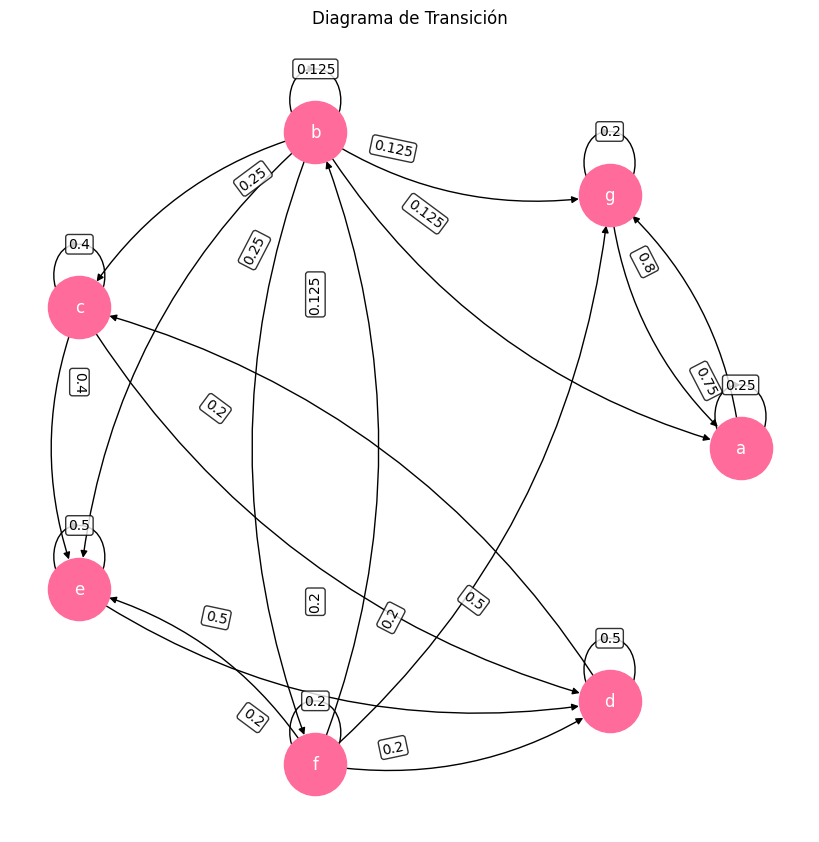

In [98]:
#1. crear el grafo
n = P.shape[0]   # número de estados
G = nx.DiGraph() # grafo dirigido

# 2. Agrear aristas con probabiliad
# Recorremos la matriz para agregar transiciones
for i in range(n):
    for j in range(n):
        if P[i, j] != 0:
            # Se agrega una arista del estado i al estado j
            G.add_edge(i, j, weight=float(P[i, j]))

# 3. renombrar nodos
nodos = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
mapping = {i: nodos[i] for i in range(n)}
G = nx.relabel_nodes(G, mapping)

# 4. Dibujar el diagrama de transición
plt.figure(figsize=(8,8))

# Posición circular de los nodos
pos = nx.circular_layout(G)
pos = {k: v * 1.5 for k, v in pos.items()}  # separa más los nodos

# Dibujar nodos y aristas
nx.draw(G, pos,
        with_labels=True,
        node_color='#FF6B9A',
        node_size=2000,
        font_color='white',
        connectionstyle='arc3,rad=0.2')

# Etiquetas de probabilidades
edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    label_pos=0.25,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
)

# Título del gráfico
plt.title("Diagrama de Transición")

# Mostrar gráfico
plt.show()

### Clasificación de los estados

1. comunicación

Para clasificar los estados de la cadena de Markov, utilizamos el concepto de comunicación.

Dos estados $i$ y $j$ se comunican si:

$$
i \leftrightarrow j \iff i \to j \ \text{y} \ j \to i
$$

es decir, si es posible ir de $i$ a $j$ y regresar de $j$ a $i$ en un número finito de pasos.



A partir del diagrama de transición se observa lo siguiente:

- El estado $a$ se comunica con $g$, ya que:
$$
a \to g \quad \text{y} \quad g \to a
$$

- El estado $b$ se comunica con $f$, puesto que:
$$
b \to f \quad \text{y} \quad f \to b
$$

- Los estados $c$, $d$ y $e$ se comunican entre sí, ya que existen caminos entre todos ellos:
$$
c \leftrightarrow d, \quad c \leftrightarrow e, \quad d \leftrightarrow e
$$

Por lo tanto, se tienen tres clases de comunicación:

$$
\{a,g\}, \quad \{b,f\}, \quad \{c,d,e\}
$$



2. Clases cerradas

Cada una de estas clases es **cerrada**, ya que no existen transiciones hacia estados fuera de la clase.

Por lo tanto, todos los estados son:

$$
\text{recurrentes}
$$

Esto implica que, una vez que la cadena entra en alguna de estas clases, permanecerá en ella para todo tiempo futuro.


3. Periodo de los estados

El periodo de un estado $i$ se define como:

$$
d(i) = \gcd \{ n \geq 1 : P^n(i,i) > 0 \}
$$

Observando la matriz de transición, se tiene que algunos estados poseen probabilidad de permanecer en sí mismos en un solo paso, por ejemplo:

$$
P(c \to c) > 0, \quad P(d \to d) > 0, \quad P(e \to e) > 0
$$

Por lo tanto:

$$
d(i) = 1
$$

para todos los estados, lo que implica que la cadena es:

$$
\text{aperiódica}
$$


Finalmente el analisis de la cadena de Markov se descompone en tres clases de comunicación disjuntas:

$$
\{a,g\}, \quad \{b,f\}, \quad \{c,d,e\}
$$

Cada una de estas clases es cerrada y está formada por estados recurrentes.

Además, todos los estados son aperiódicos, es decir:

$$
d(i) = 1
$$

para todo estado $i \in E$.

Finalmente, la cadena **no es irreducible**, ya que no todos los estados se comunican entre sí.

# 2. Determine si la matriz de transición $P$ tiene o no distribución límite


### Definición

Se dice que una cadena de Markov tiene **distribución límite** si existe un vector de probabilidad $\pi$ tal que:

$$
\lim_{n \to \infty} P^n =
\begin{pmatrix}
\pi \\
\pi \\
\vdots \\
\pi
\end{pmatrix}
$$

es decir, si todas las filas de $P^n$ convergen al mismo vector $\pi$, independientemente del estado inicial.




### Análisis de la cadena

Del inciso anterior se obtuvo que el espacio de estados se descompone en las siguientes clases de comunicación:

$$
\{a,g\}, \quad \{b,f\}, \quad \{c,d,e\}
$$

Además:

- Cada clase es **cerrada**
- Todos los estados son **recurrentes**
- La cadena es **aperiódica**
- La cadena **no es irreducible**


###Consecuencia

Para que exista una **distribución límite única**, es necesario que la cadena sea:

$$
\text{irreducible y aperiódica}
$$

Sin embargo, en este caso:

$$
\text{la cadena no es irreducible}
$$

ya que existen varias clases de comunicación disjunta.

En conclusión Dado que la cadena no es irreducible, **no existe una única distribución límite global** independiente del estado inicial.

Es decir:

$$
\lim_{n \to \infty} P^n \ \text{no converge a una matriz con filas iguales}
$$


###Observación importante

Aunque no existe una distribución límite global, cada clase de comunicación posee su propia distribución estacionaria.

Por lo tanto, el comportamiento límite de la cadena depende de la clase en la que se encuentre inicialmente.

Esto significa que la evolución a largo plazo del sistema no es única, sino que depende del estado inicial, ya que la cadena queda "atrapada" en la clase de comunicación correspondiente.






Primero analizamos si la matriz es regular, para ello calculamos algunas potencias de la matriz $P$.

Al calcular $P^2$, $P^3$, se observa que existen entradas que permanecen en cero en las mismas posiciones.

Esto ocurre porque la cadena de Markov no es irreducible, ya que el espacio de estados se descompone en varias clases de comunicación disjuntas:

$$
\{a,g\}, \quad \{b,f\}, \quad \{c,d,e\}
$$

Debido a esto, no es posible que exista un entero $n$ tal que:

$$
P^n > 0
$$

por lo implica que la matriz no es regular.


In [99]:
# Calculamos algunas potencias de la matriz
P2 = P**2
P2



Matrix([
[  0.6625,        0,       0,    0,       0,        0,   0.3375],
[0.146875, 0.040625, 0.13125,  0.2, 0.28125, 0.040625, 0.159375],
[       0,        0,    0.26, 0.38,    0.36,        0,        0],
[       0,        0,    0.45, 0.35,     0.2,        0,        0],
[       0,        0,    0.25,  0.5,    0.25,        0,        0],
[   0.185,    0.065,    0.15, 0.24,    0.19,    0.065,    0.105],
[    0.36,        0,       0,    0,       0,        0,     0.64]])

In [100]:
P3=P**3
P3

Matrix([
[   0.435625,           0,          0,     0,          0,           0,    0.564375],
[0.169296875, 0.013203125, 0.16265625, 0.275, 0.21140625, 0.013203125, 0.155234375],
[          0,           0,      0.294, 0.422,      0.284,           0,           0],
[          0,           0,      0.355, 0.365,       0.28,           0,           0],
[          0,           0,       0.35, 0.425,      0.225,           0,           0],
[   0.138375,    0.021125,    0.19625, 0.258,    0.18425,    0.021125,    0.180875],
[      0.602,           0,          0,     0,          0,           0,       0.398]])

Dado que la matriz no es regular y la cadena no es irreducible, no existe una distribución límite única independiente del estado inicial.

Es decir, el límite:

$$
\lim_{n \to \infty} P^n
$$

no converge a una matriz con filas iguales.

Sin embargo, cada clase de comunicación posee su propia distribución estacionaria, por lo que el comportamiento límite depende de la clase de comunicación en la que se encuentre el sistema.

En otras palabras.

$$
\text{la cadena no tiene una distribución límite única}
$$

# 3. Descomposición canónica y límite de $P^n$
Escriba la descomposición canónica de la matriz, determine el límite de la potencia $n$-ésima y compare contra las distribuciones límite de las submatrices.


# 3. Descomposición canónica

### Clasificación de los estados

De acuerdo con el análisis previo, las clases de comunicación son:

$$
\{a,g\}, \quad \{b,f\}, \quad \{c,d,e\}
$$

Cada una de estas clases es cerrada, por lo que todos los estados son:

$$
\text{recurrentes}
$$


### Forma canónica de la matriz

La descomposición canónica consiste en reorganizar la matriz de transición de tal manera que se agrupen los estados de acuerdo con sus clases de comunicación.

En este caso, como todas las clases son cerradas, la matriz se puede escribir en forma de bloques. Reordenando los estados como:

$$
(b,f) \; | \; (a,g) \; | \; (c,d,e)
$$

la matriz de transición se escribe en forma de bloques como:

$$
P =
\begin{pmatrix}
P_1 & 0 & 0 \\
0 & P_2 & 0 \\
0 & 0 & P_3
\end{pmatrix}
$$

donde:

- $P_1$ corresponde a la clase $\{b,f\}$
- $P_2$ corresponde a la clase $\{a,g\}$
- $P_3$ corresponde a la clase $\{c,d,e\}$


### Submatrices

Las submatrices asociadas son:

$$
P_1 =
\begin{pmatrix}
\frac{1}{8} & \frac{1}{8} \\
\frac{1}{5} & \frac{1}{5}
\end{pmatrix}, \quad
P_2 =
\begin{pmatrix}
\frac{1}{4} & \frac{3}{4} \\
\frac{4}{5} & \frac{1}{5}
\end{pmatrix}
$$

$$
P_3 =
\begin{pmatrix}
\frac{2}{5} & \frac{1}{5} & \frac{2}{5} \\
\frac{1}{2} & \frac{1}{2} & 0 \\
0 & \frac{1}{2} & \frac{1}{2}
\end{pmatrix}
$$




In [101]:
#Matriz canónica (reordenada)

Pcan = sp.Matrix([
    [1/8, 1/8, 1/8, 1/8, 1/4, 0, 1/4],
    [1/5, 1/5, 0,   1/5, 0,   1/5, 1/5],
    [0,   0,   1/4, 3/4, 0,   0,   0],
    [0,   0,   4/5, 1/5, 0,   0,   0],
    [0,   0,   0,   0,   2/5, 1/5, 2/5],
    [0,   0,   0,   0,   1/2, 1/2, 0],
    [0,   0,   0,   0,   0,   1/2, 1/2]
])

Pcan

Matrix([
[0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
[  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2],
[    0,     0,  0.25,  0.75,    0,   0,    0],
[    0,     0,   0.8,   0.2,    0,   0,    0],
[    0,     0,     0,     0,  0.4, 0.2,  0.4],
[    0,     0,     0,     0,  0.5, 0.5,    0],
[    0,     0,     0,     0,    0, 0.5,  0.5]])

In [102]:
# Submatrices asociadas a cada clase
# Clase {b,f}
sub1 = sp.Matrix([[1/8, 1/8],
                  [1/5, 1/5]])

sub1

Matrix([
[0.125, 0.125],
[  0.2,   0.2]])

In [103]:
# Clase {a,g}
sub2 = sp.Matrix([[1/4, 3/4],
                  [4/5, 1/5]])

sub2

Matrix([
[0.25, 0.75],
[ 0.8,  0.2]])

In [104]:
# Clase {c,d,e}
sub3 = sp.Matrix([[2/5, 1/5, 2/5],
                  [1/2, 1/2, 0],
                  [0, 1/2, 1/2]])

sub3


Matrix([
[0.4, 0.2, 0.4],
[0.5, 0.5,   0],
[  0, 0.5, 0.5]])

### Potencias de la matriz
Al elevar la matriz canónica a una potencia $n$, se obtiene:

$$
P^n =
\begin{pmatrix}
P_1^n & 0 & 0 \\
0 & P_2^n & 0 \\
0 & 0 & P_3^n
\end{pmatrix}
$$

Esto implica que cada bloque evoluciona de manera independiente.
Para analizar el comportamiento límite, se calculan potencias altas de cada submatriz.

Al calcular $P_1^{10}$, $P_2^{10}$ y $P_3^{10}$ se observa que:

- Cada submatriz converge a una matriz con filas iguales.
- Estas filas corresponden a la distribución estacionaria de cada bloque.

Es decir:

$$
\lim_{n \to \infty} P_i^n =
\begin{pmatrix}
\pi_i \\
\pi_i \\
\vdots
\end{pmatrix}
$$




In [105]:
sub1**10

Matrix([
[5.05661934518814e-6, 5.05661934518814e-6],
[8.09059095230103e-6, 8.09059095230103e-6]])

In [106]:
sub2**10

Matrix([
[0.517354654010254, 0.482645345989746],
[0.514821702389063, 0.485178297610938]])

In [107]:
sub3**10

Matrix([
[0.3333117166, 0.4000406558, 0.2666476276],
[0.3333095345, 0.3999736235,  0.266716842],
[0.3333960525,  0.399988745, 0.2666152025]])

Se observa que los bloques de $P_{can}^n$ coinciden exactamente con las potencias de cada submatriz:

$$
P_{can}^n =
\begin{pmatrix}
P_1^n & 0 & 0 \\
0 & P_2^n & 0 \\
0 & 0 & P_3^n
\end{pmatrix}
$$

En conclusión el límite de la potencia n-ésima de la matriz está determinado por los límites de cada submatriz.

Por lo tanto:

$$
\lim_{n \to \infty} P^n
$$

no es único, sino que depende de la clase de comunicación a la que pertenece el estado inicial.

# 4. Programa para la descomposición canónica

Escriba un programa que encuentre la descomposición canónica de una matriz de transición dada.


La descomposición canónica de una matriz de transición permite reorganizar los estados de una cadena de Markov de acuerdo con su estructura de comunicación.

Para ello, es necesario:

1. Determinar los conjuntos de alcanzabilidad:
$$
R(i) = \{ j : i \to j \}
$$

2. Identificar las clases de comunicación, es decir:
$$
i \leftrightarrow j \iff i \to j \text{ y } j \to i
$$

3. Clasificar las clases en:
- clases cerradas (estados recurrentes)
- clases no cerradas (estados transitorios)

4. Reordenar la matriz agrupando primero los estados recurrentes y posteriormente los transitorios.



### Objetivo

Construir un algoritmo que, dada una matriz de transición $P$, devuelva:

$$
\text{su forma canónica}
$$

respetando la estructura en bloques de la cadena de Markov.

In [108]:
import sympy as sp

def canonica(P):
    """
    Calcula la descomposición canónica de una matriz de transición P.

    Parámetros:
    P : matriz de transición (SymPy)

    Retorna:
    - Matriz reorganizada en forma canónica
    """

    n = P.shape[0]

    # --------------------------------------------------
    # Paso 1: Función de alcanzabilidad R(i)
    # --------------------------------------------------
    # Devuelve los estados alcanzables desde i
    def R(i):
        s = {i}
        stack = [i]

        while stack:
            u = stack.pop()
            for v in range(n):
                if P[u,v] != 0 and v not in s:
                    s.add(v)
                    stack.append(v)

        return s

    # --------------------------------------------------
    # Paso 2: Encontrar clases de comunicación
    # --------------------------------------------------
    no = set(range(n))
    clases = []

    while no:
        i = next(iter(no))
        Ri = R(i)

        # Estados que se comunican con i
        c = {j for j in Ri if i in R(j)}

        clases.append(c)
        no -= c

    print("Clases de comunicación:")
    for c in clases:
        print(c)

    # --------------------------------------------------
    # Paso 3: Identificar clases cerradas (recurrentes)
    # --------------------------------------------------
    T = set()

    for c in clases:
        cerrada = True

        for i in c:
            for j in range(n):
                if P[i,j] != 0 and j not in c:
                    cerrada = False

        if cerrada:
            T |= c

    # --------------------------------------------------
    # Paso 4: Estados transitorios
    # --------------------------------------------------
    T = list(T)  # recurrentes
    Rr = [i for c in clases for i in c if i not in T]

    print("\nEstados recurrentes:", T)
    print("Estados transitorios:", Rr)

    # --------------------------------------------------
    # Paso 5: Orden final
    # --------------------------------------------------
    orden = T + Rr

    print("\nOrden de estados:", orden)

    # --------------------------------------------------
    # Paso 6: Matriz canónica
    # --------------------------------------------------
    P_can = P.extract(orden, orden)

    print("\nMatriz en forma canónica:")
    sp.pprint(P_can)

    return P_can

In [109]:
p_can= canonica(P)

Clases de comunicación:
{0, 6}
{1, 5}
{2, 3, 4}

Estados recurrentes: [0, 2, 3, 4, 6]
Estados transitorios: [1, 5]

Orden de estados: [0, 2, 3, 4, 6, 1, 5]

Matriz en forma canónica:
⎡0.25    0     0    0    0.75     0      0  ⎤
⎢                                           ⎥
⎢  0    0.4   0.2  0.4     0      0      0  ⎥
⎢                                           ⎥
⎢  0    0.5   0.5   0      0      0      0  ⎥
⎢                                           ⎥
⎢  0     0    0.5  0.5     0      0      0  ⎥
⎢                                           ⎥
⎢ 0.8    0     0    0     0.2     0      0  ⎥
⎢                                           ⎥
⎢0.125  0.25   0   0.25  0.125  0.125  0.125⎥
⎢                                           ⎥
⎣  0     0    0.2  0.2    0.2    0.2    0.2 ⎦


El programa desarrollado permite obtener de manera automática la descomposición canónica de una matriz de transición.

A partir de la matriz $P$, el algoritmo:

- Identifica las clases de comunicación
- Clasifica los estados en recurrentes y transitorios
- Reorganiza la matriz en forma de bloques

Esto facilita el análisis estructural de la cadena de Markov, permitiendo observar de manera clara su comportamiento a largo plazo.



La descomposición canónica es una herramienta fundamental, ya que:

$$
\text{permite estudiar cada clase de comunicación de manera independiente}
$$

y entender cómo evoluciona el sistema en función del estado inicial.